### Set up dataset

In [1]:
import os
path = os.getenv('DATA_PATH')
token = os.getenv('API_TOKEN')

In [2]:
from a3em_analysis.datasets import Arden

dataset = Arden(path, token)
dataset.load_data(random_state=123, rumble_only=True)
metadata = dataset.metadata

prefetch complete
extracting features


100%|██████████| 62/62 [01:06<00:00,  1.07s/it]


### Duration over time

In [3]:
from datetime import datetime, timedelta

def parse_abs_start(row):
    parts = row['file_stem'].split('_')
    rec_start = datetime.strptime(parts[1] + parts[2], '%Y%m%d%H%M%S')
    return rec_start + timedelta(seconds=row['Begin Time (s)'])

In [4]:
metadata['abs_start'] = [parse_abs_start(row) for _, row in metadata.iterrows()]
metadata.head()

,file_stem,Begin Time (s),End Time (s),call_type,quality,overlap,earflap,duration,abs_start
0,Arden_20250607_050010,170.571151,175.953214,RUM,3,N,1,5.382062,2025-06-07 05:03:00.571151
1,Arden_20250606_150100,2356.943538,2362.128695,RUM,2,N,1,5.185158,2025-06-06 15:40:16.943538
2,Arden_20250606_220135,602.506150,608.075457,RUM,2,N,0,5.569307,2025-06-06 22:11:37.506150
3,Arden_20250607_190120,2322.122380,2327.227578,RUM,3,N,1,5.105198,2025-06-07 19:40:02.122380
4,Arden_20250608_230140,1860.792184,1863.576838,RUM,2,N,0,2.784653,2025-06-08 23:32:40.792184


<BarContainer object of 705 artists>

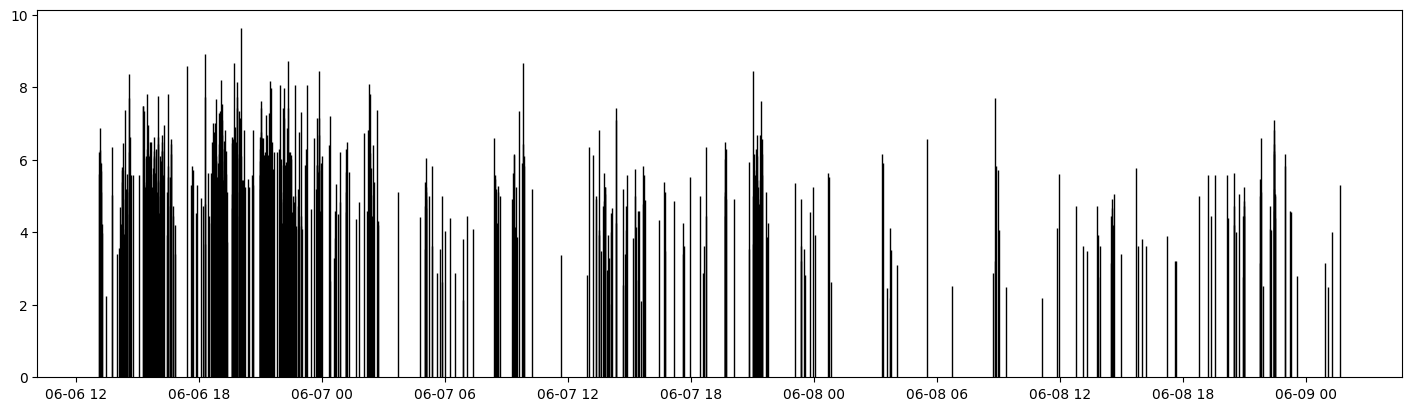

In [5]:
import matplotlib.pyplot as plt

time = metadata['abs_start'].to_numpy()
call_duration = metadata['duration'].to_numpy()

fig, ax = plt.subplots(figsize=(14, 4), layout='constrained')
ax.bar(time, call_duration, width=1, edgecolor="black", linewidth=1)


#### Peak Frequency Over Time

In [6]:
features, _ = dataset.load_data()
features.head()

,peak_freq,centroid,bandwidth,freq_5,freq_95,hnr,hnr_low,mfcc_1,mfcc_2,mfcc_3,...,mel_mean_17,mel_mean_18,mel_mean_19,mel_mean_20,mel_mean_21,mel_mean_22,mel_mean_23,mel_mean_24,mel_mean_25,mel_mean_26
0,23.437500,178.779956,133.835880,36.132812,131.835938,-1.776016,-0.076326,-198.986684,239.842074,-40.714127,...,0.004546,0.001320,0.000364,0.000096,0.000024,0.000011,0.000010,0.000009,0.000009,0.000009
1,46.875000,147.315745,120.647897,34.179688,160.156250,-7.907223,-8.424224,-309.532524,235.805844,-13.067658,...,0.000237,0.000064,0.000011,0.000004,0.000002,0.000002,0.000002,0.000002,0.000002,0.000002
2,23.437500,194.163404,136.806571,32.226562,198.242188,-8.642805,-3.842762,-194.467466,236.761612,-48.051682,...,0.005507,0.001716,0.000412,0.000083,0.000029,0.000008,0.000005,0.000004,0.000004,0.000004
3,22.460938,151.158718,122.707804,37.109375,125.976562,-3.056880,-2.705753,-207.761279,243.125815,-22.173188,...,0.001051,0.000363,0.000063,0.000022,0.000011,0.000008,0.000008,0.000007,0.000007,0.000007
4,32.226562,250.617734,155.907884,42.968750,450.195312,4.508551,9.058329,-124.077526,237.173680,-91.292423,...,0.044213,0.010921,0.003966,0.000878,0.000247,0.000046,0.000014,0.000007,0.000005,0.000004


<BarContainer object of 705 artists>

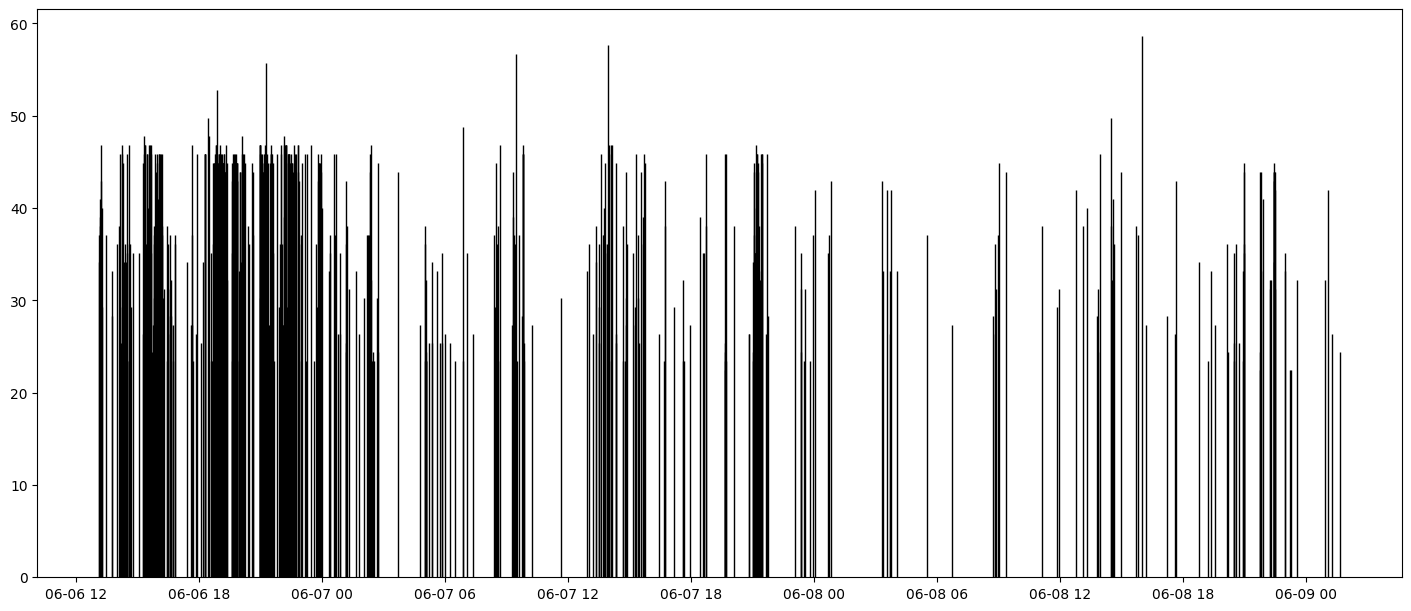

In [7]:
import matplotlib.pyplot as plt

time = metadata['abs_start'].to_numpy()
peak_freq = features['peak_freq'].to_numpy()

fig, ax = plt.subplots(figsize=(14, 6), layout='constrained')
ax.bar(time, peak_freq, width=1, edgecolor="black", linewidth=1)